In [14]:
!pip install duckdb

In [15]:

import duckdb
import pandas as pd

In [16]:
DB_PATH = "../house_prices.duckdb"
con = duckdb.connect(DB_PATH)

In [17]:
tables = con.execute("SHOW TABLES").df()
print(tables)


                  name
0       epc_kent_clean
1         epc_kent_raw
2  land_registry_clean
3    land_registry_raw


In [19]:
row_counts = con.execute("""
SELECT 
    'land_registry_clean' AS table_name, COUNT(*) AS rows FROM land_registry_clean
UNION ALL
SELECT 'epc_kent_clean', COUNT(*) FROM epc_kent_clean
""").df()
print(row_counts)

            table_name    rows
0  land_registry_clean  118657
1       epc_kent_clean  196680


In [47]:
df_land_registry = con.execute("SELECT * FROM land_registry_clean").df()
print(df_land_registry.head())


    price date_of_transfer  postcode property_type new_build_flag duration  \
0  150000       2021-07-23  CT20 2DE             F              N        L   
1  115000       2021-08-03  ME15 6ZL             F              N        L   
2   67500       2021-06-01   TN9 1FT             F              N        L   
3  283000       2021-03-26  ME10 5BJ             S              N        F   
4  358000       2021-05-06  TN10 4JX             S              N        F   

    town           city               district county  
0   None     FOLKESTONE   FOLKESTONE AND HYTHE   KENT  
1  TOVIL      MAIDSTONE              MAIDSTONE   KENT  
2   None      TONBRIDGE  TONBRIDGE AND MALLING   KENT  
3   None  SITTINGBOURNE                  SWALE   KENT  
4   None      TONBRIDGE  TONBRIDGE AND MALLING   KENT  


In [48]:
#Get column names
column_names_land_registry = df_land_registry.columns
print(column_names_land_registry)

Index(['price', 'date_of_transfer', 'postcode', 'property_type',
       'new_build_flag', 'duration', 'town', 'city', 'district', 'county'],
      dtype='object')


In [24]:
#Get total count of values for each column
df_land_registry.count()

price               118657
date_of_transfer    118657
postcode            117920
property_type       118657
new_build_flag      118657
duration            118657
town                 48978
city                118657
district            118657
county              118657
dtype: int64

In [22]:
df_land_registry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118657 entries, 0 to 118656
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   price             118657 non-null  int64         
 1   date_of_transfer  118657 non-null  datetime64[us]
 2   postcode          117920 non-null  object        
 3   property_type     118657 non-null  object        
 4   new_build_flag    118657 non-null  object        
 5   duration          118657 non-null  object        
 6   town              48978 non-null   object        
 7   city              118657 non-null  object        
 8   district          118657 non-null  object        
 9   county            118657 non-null  object        
dtypes: datetime64[us](1), int64(1), object(8)
memory usage: 9.1+ MB


In [23]:
df_land_registry.describe()

,price,date_of_transfer
count,1.186570e+05,118657
mean,4.420445e+05,2022-10-20 03:48:33.233943
min,1.000000e+02,2021-01-01 00:00:00
25%,2.500000e+05,2021-09-24 00:00:00
50%,3.400000e+05,2022-09-05 00:00:00
75%,4.650000e+05,2023-10-27 00:00:00
max,9.000000e+08,2024-12-30 00:00:00
std,2.813034e+06,NaN


In [28]:
#Check if any values in price is less than or equal to 0 
null_value= df_land_registry['price']<=0
print(null_value.sum())

0


In [30]:
#Drop missing postcodes
df_land_registry = df_land_registry[df_land_registry['postcode'].notna()]

In [31]:
df_land_registry['postcode'].count()

np.int64(117920)

In [32]:
#Capitalise postcode
df_land_registry['postcode'] = df_land_registry['postcode'].str.upper()

In [79]:
#remove leading and trailing white space
df_land_registry['postcode'] = df_land_registry['postcode'].str.strip()

In [33]:
df_land_registry['property_type'].unique()

array(['F', 'S', 'T', 'D', 'O'], dtype=object)

In [34]:
df_land_registry.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117920 entries, 0 to 118656
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   price             117920 non-null  int64         
 1   date_of_transfer  117920 non-null  datetime64[us]
 2   postcode          117920 non-null  object        
 3   property_type     117920 non-null  object        
 4   new_build_flag    117920 non-null  object        
 5   duration          117920 non-null  object        
 6   town              48528 non-null   object        
 7   city              117920 non-null  object        
 8   district          117920 non-null  object        
 9   county            117920 non-null  object        
dtypes: datetime64[us](1), int64(1), object(8)
memory usage: 9.9+ MB


In [35]:
#Drop column table
df_land_registry = df_land_registry.drop(columns =['town'])

In [42]:
#Check for duplicated row
print(df_land_registry.duplicated().sum())

1484


In [44]:
#Drop duplicated rows
df_land_registry = df_land_registry.drop_duplicates()


In [45]:
df_land_registry.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116436 entries, 0 to 118656
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   price             116436 non-null  int64         
 1   date_of_transfer  116436 non-null  datetime64[us]
 2   postcode          116436 non-null  object        
 3   property_type     116436 non-null  object        
 4   new_build_flag    116436 non-null  object        
 5   duration          116436 non-null  object        
 6   city              116436 non-null  object        
 7   district          116436 non-null  object        
 8   county            116436 non-null  object        
dtypes: datetime64[us](1), int64(1), object(7)
memory usage: 8.9+ MB


In [ ]:
con.execute("DROP TABLE IF EXISTS land_registry_fully_cleaned")
con.register("df_land_registry", df_land_registry)
con.execute("CREATE TABLE land_registry_fully_cleaned AS SELECT * FROM df_land_registry")

In [99]:
tables = con.execute("SHOW TABLES").df()
print(tables)

                          name
0             df_land_registry
1               epc_kent_clean
2                 epc_kent_raw
3          land_registry_clean
4  land_registry_fully_cleaned
5            land_registry_raw


In [49]:
df_epc_data = con.execute("SELECT * FROM epc_kent_clean").df()
print(df_epc_data.head())


   POSTCODE  TOTAL_FLOOR_AREA  NUMBER_HABITABLE_ROOMS PROPERTY_TYPE  \
0  CT13 0AL              81.0                       4         House   
1  CT17 0BA              94.0                       5         House   
2  CT17 9FB              46.0                       2          Flat   
3   CT3 3GZ              64.0                    <NA>          Flat   
4   CT3 1FX             139.0                    <NA>         House   

          CONSTRUCTION_AGE_BAND CURRENT_ENERGY_RATING LODGEMENT_DATE  
0  England and Wales: 1950-1966                     D     2021-07-01  
1  England and Wales: 1930-1949                     D     2021-07-01  
2  England and Wales: 1996-2002                     C     2021-07-02  
3                          2021                     B     2021-07-21  
4                          2021                     B     2021-09-21  


In [50]:
#Get column names
column_names_epc_data = df_epc_data.columns
print(column_names_epc_data)

Index(['POSTCODE', 'TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS',
       'PROPERTY_TYPE', 'CONSTRUCTION_AGE_BAND', 'CURRENT_ENERGY_RATING',
       'LODGEMENT_DATE'],
      dtype='object')


In [51]:
#Get total count of values
df_epc_data.count()

POSTCODE                  196680
TOTAL_FLOOR_AREA          196680
NUMBER_HABITABLE_ROOMS    164054
PROPERTY_TYPE             196680
CONSTRUCTION_AGE_BAND     195054
CURRENT_ENERGY_RATING     196680
LODGEMENT_DATE            196680
dtype: int64

In [52]:
df_epc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196680 entries, 0 to 196679
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   POSTCODE                196680 non-null  object        
 1   TOTAL_FLOOR_AREA        196680 non-null  float64       
 2   NUMBER_HABITABLE_ROOMS  164054 non-null  Int64         
 3   PROPERTY_TYPE           196680 non-null  object        
 4   CONSTRUCTION_AGE_BAND   195054 non-null  object        
 5   CURRENT_ENERGY_RATING   196680 non-null  object        
 6   LODGEMENT_DATE          196680 non-null  datetime64[us]
dtypes: Int64(1), datetime64[us](1), float64(1), object(4)
memory usage: 10.7+ MB


In [53]:
df_epc_data.describe()

,TOTAL_FLOOR_AREA,NUMBER_HABITABLE_ROOMS,LODGEMENT_DATE
count,196680.000000,164054.0,196680
mean,87.459843,4.171633,2022-12-18 02:27:31.299572
min,1.000000,1.0,2021-01-01 00:00:00
25%,60.000000,3.0,2022-01-18 00:00:00
50%,77.000000,4.0,2022-11-29 00:00:00
75%,98.000000,5.0,2023-12-04 00:00:00
max,4288.000000,45.0,2024-12-31 00:00:00
std,52.340105,1.765021,NaN


In [55]:
#Capitalise postcode
df_epc_data['POSTCODE'] = df_epc_data['POSTCODE'].str.upper()

In [80]:
#remove leading and trailing white space
df_epc_data['POSTCODE'] = df_epc_data['POSTCODE'].str.strip()

In [57]:
#Check if total floor area has value less than or equal to 0
print((df_epc_data['TOTAL_FLOOR_AREA']<=0).sum())

0


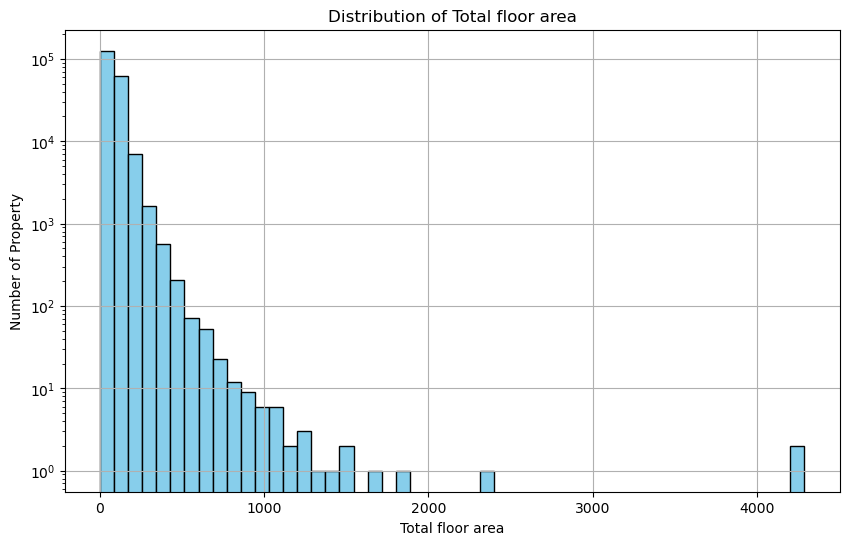

In [63]:
#Visualise the distribution of floor area to see if there are any outliers
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
#log=True to see smaller bins
plt.hist(df_epc_data['TOTAL_FLOOR_AREA'], bins=50, color='skyblue', edgecolor='black', log=True)
plt.title('Distribution of Total floor area')
plt.xlabel('Total floor area')
plt.ylabel('Number of Property')
plt.grid(True)
plt.show()

In [69]:

print((df_epc_data['TOTAL_FLOOR_AREA']>2000).sum())

3


In [70]:
#Drop those property with floor area greater than 2000 because this might skew the data
df_epc_data = df_epc_data[df_epc_data['TOTAL_FLOOR_AREA']<=2000]

In [71]:
#Check unique values for property type
df_epc_data['PROPERTY_TYPE'].unique()

array(['House', 'Flat', 'Bungalow', 'Maisonette', 'Park home'],
      dtype=object)

In [81]:
df_epc_data['PROPERTY_TYPE'] = df_epc_data['PROPERTY_TYPE'].str.strip()

In [82]:
#Replace the missing NUMBER_HABITABLE_ROOMS with median(not skewed by outliers) 
median_habitable_rooms = int(df_epc_data['NUMBER_HABITABLE_ROOMS'].median())
df_epc_data['NUMBER_HABITABLE_ROOMS'] = df_epc_data['NUMBER_HABITABLE_ROOMS'].fillna(median_habitable_rooms) 

In [83]:
df_epc_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196677 entries, 0 to 196679
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   POSTCODE                196677 non-null  object        
 1   TOTAL_FLOOR_AREA        196677 non-null  float64       
 2   NUMBER_HABITABLE_ROOMS  196677 non-null  Int64         
 3   PROPERTY_TYPE           196677 non-null  object        
 4   CONSTRUCTION_AGE_BAND   196677 non-null  object        
 5   CURRENT_ENERGY_RATING   196677 non-null  object        
 6   LODGEMENT_DATE          196677 non-null  datetime64[us]
dtypes: Int64(1), datetime64[us](1), float64(1), object(4)
memory usage: 12.2+ MB


In [84]:
df_epc_data["CONSTRUCTION_AGE_BAND"].value_counts(dropna=False)


CONSTRUCTION_AGE_BAND
England and Wales: 1950-1966       31795
England and Wales: 1967-1975       21968
England and Wales: 1900-1929       19908
England and Wales: 1930-1949       17890
England and Wales: before 1900     17739
England and Wales: 1983-1990       11925
England and Wales: 1976-1982       10849
2021                                8037
England and Wales: 1996-2002        7815
England and Wales: 2007-2011        7793
England and Wales: 2003-2006        7375
2022                                6306
England and Wales: 1991-1995        6002
2023                                5229
2019                                3969
England and Wales: 2012 onwards     3065
2020                                2850
2024                                2400
UNKNOWN                             1626
2018                                1268
2017                                 566
2016                                 135
2013                                  64
2015                               

In [85]:
#Fill null values with UNKNOWN
df_epc_data['CONSTRUCTION_AGE_BAND'] = df_epc_data['CONSTRUCTION_AGE_BAND'].fillna("UNKNOWN")

In [86]:
df_epc_data['CONSTRUCTION_AGE_BAND'] = df_epc_data['CONSTRUCTION_AGE_BAND'].str.strip()

In [92]:
#Check if there are any lowercase letters 
df_epc_data['CURRENT_ENERGY_RATING'].unique()

array(['D', 'C', 'B', 'E', 'G', 'F', 'A'], dtype=object)

In [94]:
#Remove leading and trailing white spaces if any
df_epc_data['CURRENT_ENERGY_RATING'] = df_epc_data['CURRENT_ENERGY_RATING'].str.strip()


In [95]:
df_epc_data.head()

,POSTCODE,TOTAL_FLOOR_AREA,NUMBER_HABITABLE_ROOMS,PROPERTY_TYPE,CONSTRUCTION_AGE_BAND,CURRENT_ENERGY_RATING,LODGEMENT_DATE
0,CT13 0AL,81.0,4,House,England and Wales: 1950-1966,D,2021-07-01
1,CT17 0BA,94.0,5,House,England and Wales: 1930-1949,D,2021-07-01
2,CT17 9FB,46.0,2,Flat,England and Wales: 1996-2002,C,2021-07-02
3,CT3 3GZ,64.0,4,Flat,2021,B,2021-07-21
4,CT3 1FX,139.0,4,House,2021,B,2021-09-21


In [100]:
con.execute("DROP TABLE IF EXISTS epc_data_fully_cleaned")
con.register("df_epc_data", df_epc_data)
con.execute("CREATE TABLE epc_data_fully_cleaned AS SELECT * FROM df_epc_data")



In [101]:
tables = con.execute("SHOW TABLES").df()
print(tables)

                          name
0                  df_epc_data
1             df_land_registry
2       epc_data_fully_cleaned
3               epc_kent_clean
4                 epc_kent_raw
5          land_registry_clean
6  land_registry_fully_cleaned
7            land_registry_raw
